In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils 
import TCR_embedings


2026-03-23 15:56:01.163730: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-23 15:56:01.164130: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 15:56:01.233159: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 15:56:04.540019: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## load mdata

In [2]:
# mdata = mu.read("all_Common_DEtop2500.h5mu")   # processed
# mdata

In [3]:
path = "/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/anndata/"
mdata = mu.read(path + "all_Common.h5mu")
mdata

MuData object with n_obs × n_vars = 77660 × 33708
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num'
  2 modalities
    gex:	77660 x 33708
      obs:	'mouse_id', 'date', 'tissue'
    airr:	77660 x 0
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

In [4]:
adata_tcr = mdata['airr']

In [5]:
# check If log1p transformed
print(mdata['gex'].X.data.max() if hasattr(mdata['gex'].X, 'data') else mdata['gex'].X.max())

X0 = mdata['gex'].X[0].toarray() if hasattr(mdata['gex'].X[0], 'toarray') else mdata['gex'].X[0]
X0

491699.0


array([[ 0.,  0.,  0., ...,  7., 15.,  8.]], dtype=float32)

In [6]:
prefixes_to_remove = ('CMO', 'ENSM',
                      'Trav', 'Traj', 'Trac', 'Trbv', 'Trbj', 
                     'Trbc', 'Trdv', 'Trdj', 'Trdc', 'Trgv', 'Trgj', 'Trgc') 

TCR_gene_mask = mdata.var_names.str.startswith(prefixes_to_remove)
mdata = mdata[:, ~TCR_gene_mask]

mdata['gex'].var_names_make_unique()

## QC

In [7]:
mdata['gex'].var["mt"] = mdata['gex'].var_names.str.startswith("mt-")
# ribosomal genes
mdata['gex'].var["ribo"] = mdata['gex'].var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
mdata['gex'].var["hb"] = mdata['gex'].var_names.str.contains("^Hb[^(p)]")

sc.pp.calculate_qc_metrics(
    mdata['gex'], qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
# 

sc.pp.filter_cells(mdata['gex'], min_genes= 300)
sc.pp.filter_cells(mdata['gex'], max_genes= 7000)

sc.pp.filter_cells(mdata['gex'], min_counts=1000)
sc.pp.filter_cells(mdata['gex'], max_counts=40000)

sc.pp.filter_genes(mdata['gex'], min_cells=50)

In [8]:
# sync mdata obs
mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 76901 × 17005
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num'
  2 modalities
    gex:	76901 x 17005
      obs:	'mouse_id', 'date', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    airr:	76901 x 0
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

In [9]:
# Taking too long and no effect
# sc.pp.scrublet(mdata['gex'])
# sc.pp.scrublet(
#     mdata['gex'],
#     threshold=0.25,                
#     sim_doublet_ratio=5.0,        
#     n_neighbors=20,            
# )
# mdata = mdata[mdata['gex'].obs['predicted_doublet'] == 'True'].copy()

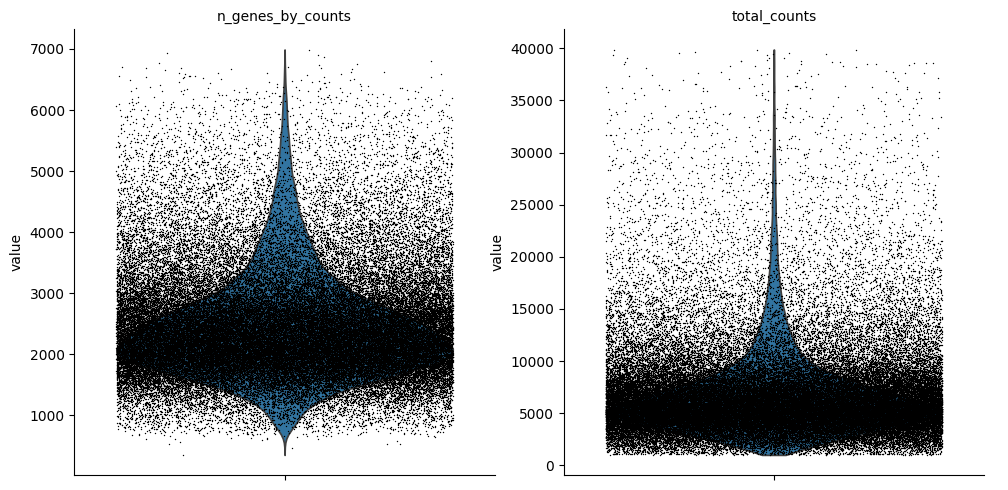

In [10]:
sc.pl.violin(
    mdata['gex'],
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [11]:
sc.pp.normalize_total(mdata['gex'])
sc.pp.log1p(mdata['gex'])

In [12]:
mdata_ori = mdata.copy()
mdata_ori

MuData object with n_obs × n_vars = 76901 × 17005
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num'
  2 modalities
    gex:	76901 x 17005
      obs:	'mouse_id', 'date', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	76901 x 0
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

In [13]:
# mdata_ori.write(path + 'all_Common_QC.h5mu')

## subset on mdata

In [14]:
mdata_ori = mu.read(path + 'all_Common_QC.h5mu')

In [15]:
mdata = mdata_ori

In [16]:
mdata['gex'].obs['manual_cell_type'] = mdata.obs['manual_cell_type']
sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=2500, batch_key="mouse_id")
mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()
mdata = mdata_utils.sync_mdata_obs(mdata)

In [17]:
mdata.obs['manual_cell_type'].value_counts()

manual_cell_type
CD4+ T       19786
CD8+ T       16828
multiplet    11285
Treg          6815
Myeloid       2726
Name: count, dtype: int64

In [18]:
# mdata = mdata[mdata['gex'].obs['tissue'] == 'SP'].copy()
mdata = mdata[mdata['gex'].obs['mouse_id'].isin(['5_3','5_4'])].copy()

mdata = mdata[~mdata['gex'].obs['manual_cell_type'].isin(['multiplet','Myeloid'])].copy()
# mdata = mdata[mdata['gex'].obs['manual_cell_type'].isin(['CD4+ T'])].copy()
mdata

MuData object with n_obs × n_vars = 12269 × 2500
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample'
  2 modalities
    gex:	12269 x 2500
      obs:	'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'manual_cell_type'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'log1p', 'hvg'
    airr:	12269 x 0
      obsm:	'airr'

In [19]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

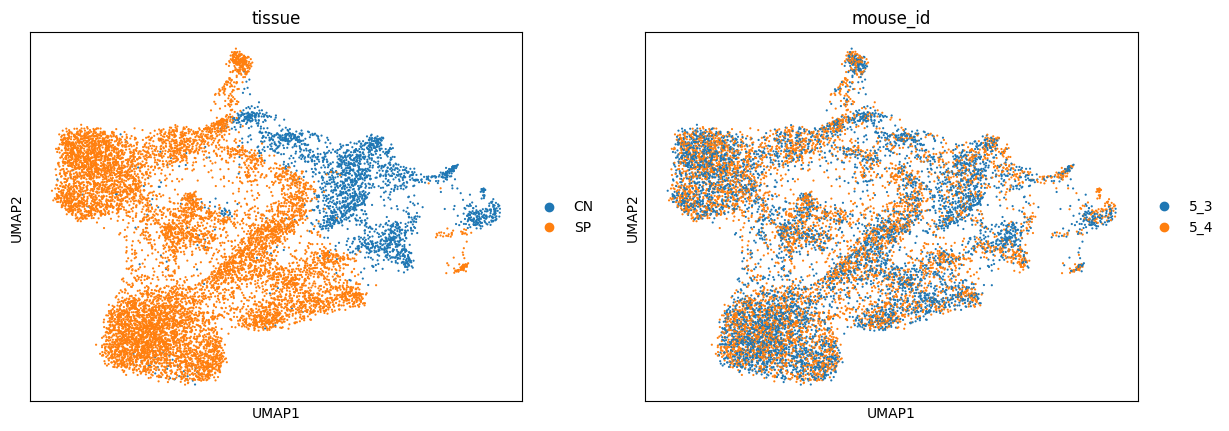

In [20]:
sc.tl.leiden(mdata["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')
sc.pl.umap(mdata["gex"], color=["tissue", "mouse_id"])

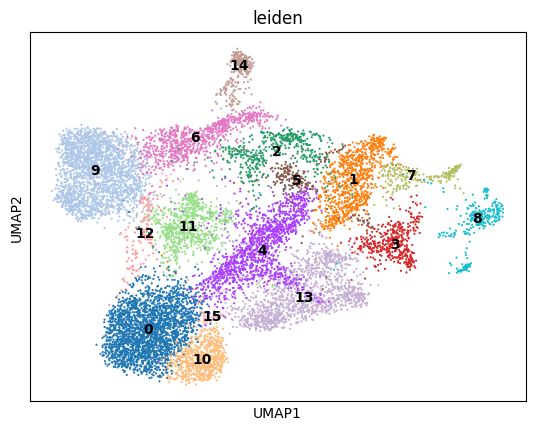

In [21]:
sc.pl.umap(mdata["gex"], color="leiden", legend_loc="on data")

### Rank markers + export CSV

In [22]:
from cluster_annotation import *

In [23]:
df_top, df_detail = rank_leiden_markers_to_csv(
    mdata["gex"],
    leiden_col="leiden",
    n_genes=20,
    output_top_genes_csv= None,    # file name if to save
)

In [24]:
import os
current_directory = os.getcwd()

results = pd.read_csv(current_directory + '/CD4_cluster_annotations.csv')
annotation_dict = dict(zip(results['Cluster'], results['Annotation']))

In [25]:
annotation_name='Auto'
assign_annotation_by_leiden(mdata["gex"], annotation_dict, annotation_name=annotation_name)

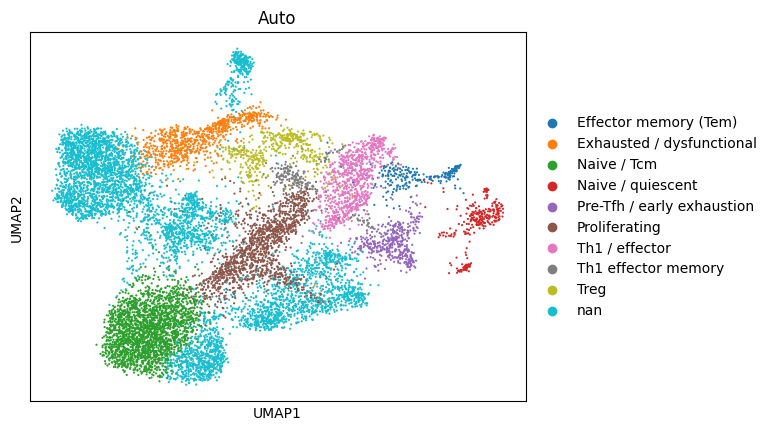

In [26]:
sc.pl.umap(mdata["gex"], color=annotation_name)

### annotate by leiden clusters

In [27]:
# state_marker = { 'Memory/Progenitor': ['Tcf7', 'Il7r', 'Ccr7'],
#             'Exhaustion': ['Lag3', 'Havcr2', 'Ctla4', 'Pdcd1', 'Tox'],
#             'Effector': ['Prf1', 'Gzmb', 'Ifng'],
#             'Proliferation': ['Mki67', 'Gins2', 'Mcm5', 'Top2a']}

state_marker = {'IFN_stim': ['Isg15', 'Gbp2', 'Ifih1'],
    'Activation': ['Icos', 'Cd69', 'Cd28'],
    'Exhaust': ['Pdcd1', 'Lag3', 'Havcr2'],
    'Mem': ['Ccr7', 'Sell', 'Cd27']}

markers = state_marker

UMAP: IFN_stim (markers: ['Isg15', 'Gbp2', 'Ifih1'])


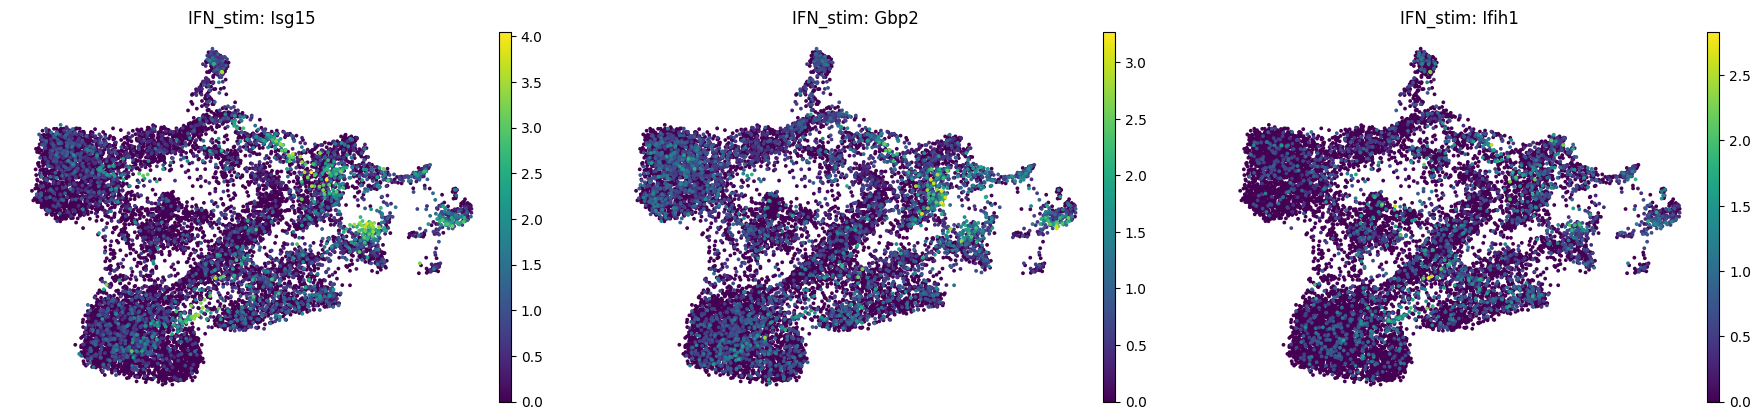

UMAP: Activation (markers: ['Icos', 'Cd69', 'Cd28'])


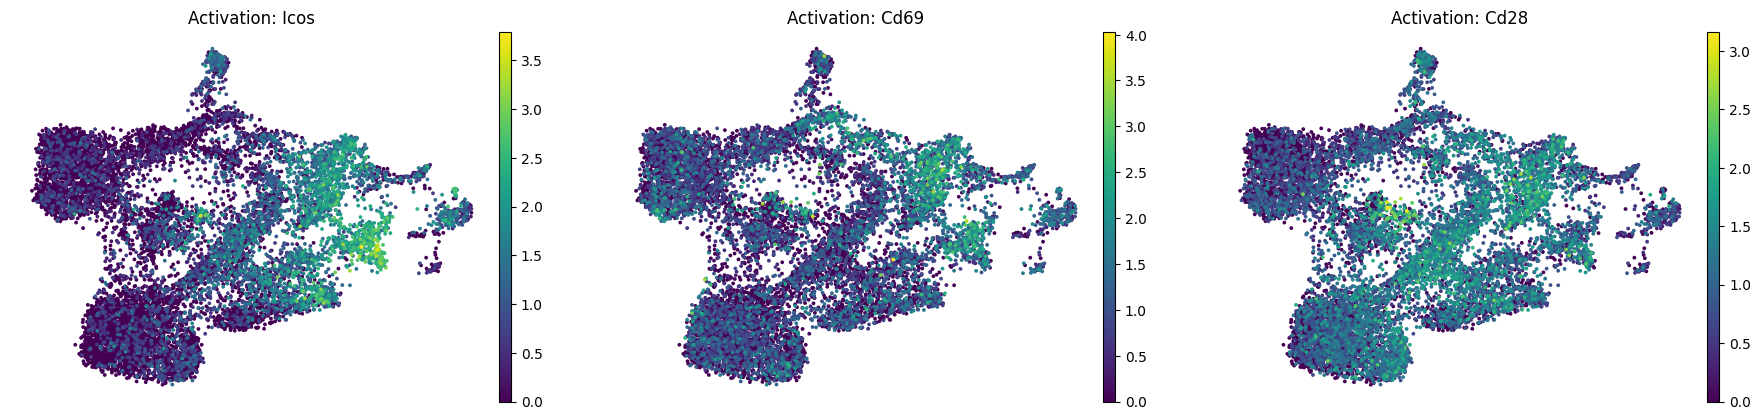

UMAP: Exhaust (markers: ['Pdcd1', 'Lag3', 'Havcr2'])


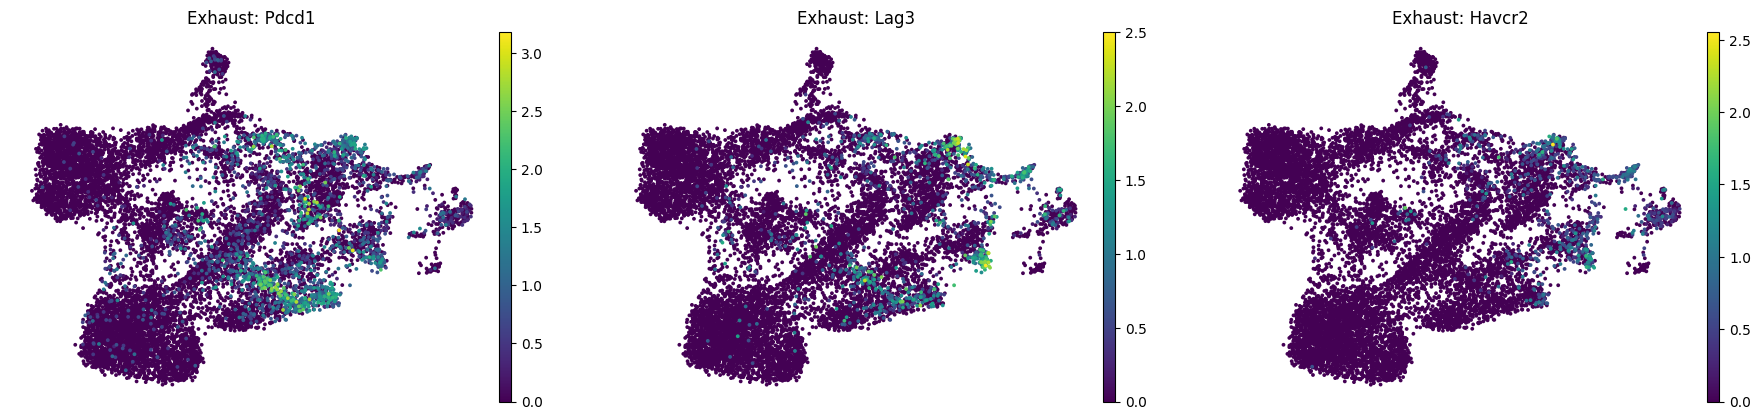

UMAP: Mem (markers: ['Ccr7'])


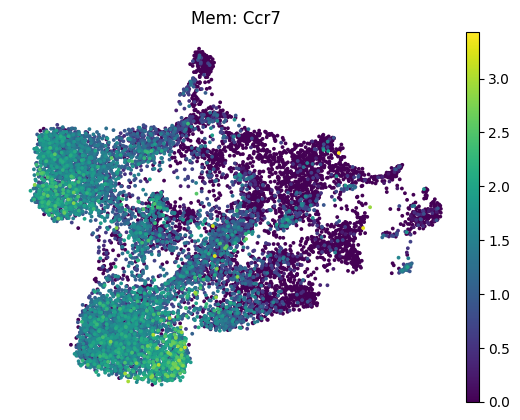

In [28]:
# 2) UMAP for gene sets in a dict
plot_umap_for_gene_dict(mdata['gex'], state_marker, show=True, save=False)

# 3) Score clusters and annotate
annotation_name = "cell_type_annotation"
cluster_scores, cluster_annotations = score_leiden_clusters_by_marker_dict(
    mdata['gex'],
    markers,
    leiden_col="leiden",
    cell_type_annotation_col=annotation_name,
)

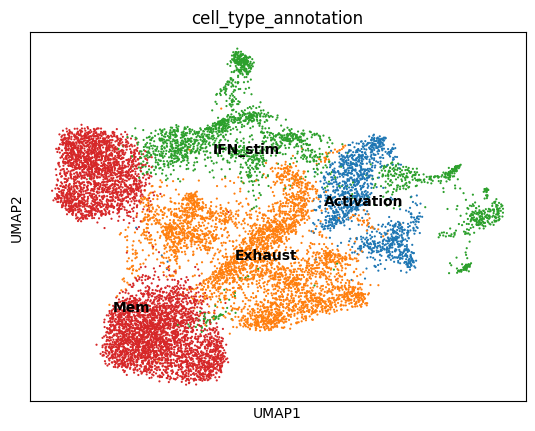

In [29]:
sc.pl.umap(mdata['gex'], color=annotation_name, legend_loc="on data")

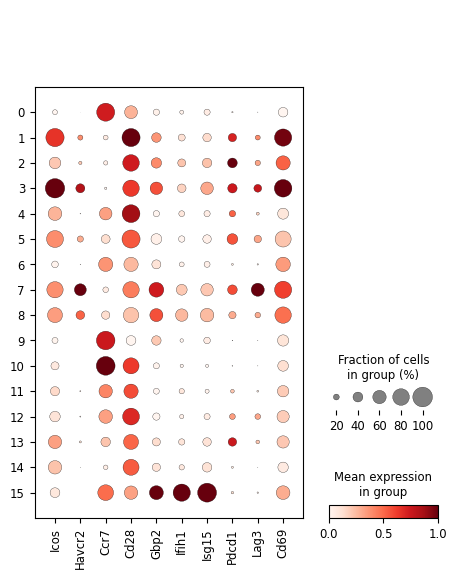

In [30]:
genes_to_plot = list({gene for genes in markers.values() for gene in genes if gene in mdata['gex'].var_names})
sc.pl.dotplot(
    mdata['gex'],
    var_names=genes_to_plot,
    groupby="leiden",
    standard_scale='var',
    show=True
)

### annotate by the highest gene set score

In [31]:
# from cluster_ import score_cells_by_marker_dict
cell_scores, best_labels = score_cells_by_marker_dict(
    mdata['gex'],
    marker_dict=markers,
    cell_type_annotation_col= "best_label",
)

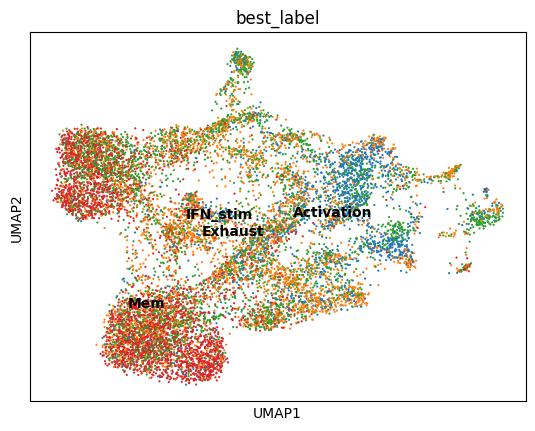

In [32]:
sc.pl.umap(mdata['gex'], color="best_label", legend_loc="on data")

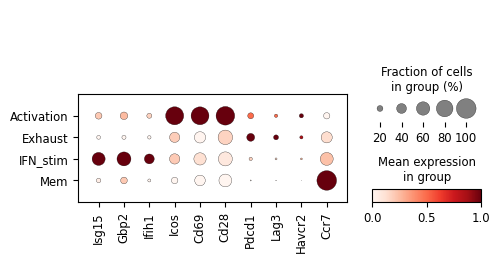

In [33]:
seen = set()
genes_to_plot = []
for genes in markers.values():
    for gene in genes:
        if gene not in seen and gene in mdata['gex'].var_names:
            seen.add(gene)
            genes_to_plot.append(gene)
            
sc.pl.dotplot(
    mdata['gex'],
    var_names=genes_to_plot,
    groupby="best_label",
    standard_scale='var',
    show=True
)

In [34]:
mdata

MuData object with n_obs × n_vars = 12269 × 2500
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample'
  2 modalities
    gex:	12269 x 2500
      obs:	'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'manual_cell_type', 'leiden', 'Auto', 'IFN_stim_score', 'Activation_score', 'Exhaust_score', 'Mem_score', 'cell_type_annotation', 'best_label'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'tissue_colors', 'mouse_id_colors', 'leiden_colors', 'rank_genes_groups', 'Auto_colors', 'cell_type_annotation_colors', 'best_label_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	12269 x 0
      obsm:	'airr'

In [35]:
# mdata.write(path + 'annotated_T_DE2500.h5mu')

## Celltypist

In [36]:
from celltypist import models
import celltypist

# Download the immune model
models.download_models(model="Immune_All_High.pkl", force_update=False)
model = models.Model.load(model="Immune_All_High.pkl")

# Convert model weights from human → mouse gene space (built-in ortholog mapping)
model_mouse = model.convert(
    map_file=None,       # uses CellTypist's built-in human-mouse ortholog table
    unique_only=True     # 1:1 orthologs only (safest)
)

mdata['gex']_ct = mdata['gex'].copy()

# Run annotation with the converted mouse model
predictions = celltypist.annotate(
    mdata['gex']_ct,
    model=model_mouse,
    majority_voting=True,
    over_clustering="leiden"   # your existing leiden key
)

mdata['gex'].obs["celltypist_cell_type"]       = predictions.predicted_labels["predicted_labels"]
mdata['gex'].obs["celltypist_over_clustering"] = predictions.predicted_labels["over_clustering"]
mdata['gex'].obs["celltypist_majority_voting"] = predictions.predicted_labels["majority_voting"]

SyntaxError: invalid syntax (290858529.py, line 14)

In [ ]:
print(predictions.predicted_labels.columns.tolist())

In [ ]:
sc.pl.umap(mdata["gex"], color="celltypist_majority_voting", legend_loc="on data")

## Manual Annotation YF

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1', 'Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra', 'Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
myloid_markers = ['Cd11b', 'Cd33', 'Cd45', 'Cd68']
markers_in = []

for i in type_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)

In [ ]:
myloid_markers = ['Cd11b', 'Cd33', 'Cd45', 'Cd68']
markers_in = []

for i in myloid_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)

In [ ]:
mdata["gex"].obs['modified_cell_type'] = 'NaN'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['2','13','6','14',])] = 'CD8+ T'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['4','7'])] = 'Treg'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['8'])] = 'CD4+ Th17'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['16'])] = 'CD4+ Th1'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['5','1','0','18','8'])] = 'CD4+ T'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['10','11'])] = 'Myloid'

mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['12','15'])] = 'CD4+ CD8+'

sc.pl.umap(mdata["gex"], color=['modified_cell_type'])

In [ ]:
markers_in = []
for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
mu.pl.embedding(mdata, basis="gex:umap", color= markers_in, wspace = 0.1, ncols=2, vmin=0)

In [ ]:
import scanpy as sc

IFN_stim = ['Isg15', 'Gbp2', 'Ifih1']
Activation = ['Icos', 'Cd69', 'Cd28']
Exhaust = ['Pdcd1', 'Lag3', 'Havcr2']
Mem = ['Ccr7', 'Sell', 'Cd27']

sc.tl.score_genes(mdata['gex'], gene_list=IFN_stim, score_name='IFN_stim')
sc.tl.score_genes(mdata['gex'], gene_list=Activation, score_name='Activation')
sc.tl.score_genes(mdata['gex'], gene_list=Exhaust, score_name='Exhaust')
sc.tl.score_genes(mdata['gex'], gene_list=Mem, score_name='Mem')

In [ ]:
# mdata['gex'].obs['state'] = 'Effector'
mdata['gex'].obs.loc[mdata['gex'].obs['Exhaust'] > 0.5, 'state'] = 'Exhausted'
mdata['gex'].obs.loc[mdata['gex'].obs['Mem'] > 0.5, 'state'] = 'Mem'
mdata['gex'].obs.loc[mdata['gex'].obs['IFN_stim'] > 0.5, 'state'] = 'activated'
mdata['gex'].obs.loc[mdata['gex'].obs['Activation'] > 0.5, 'state'] = 'activated'


In [ ]:
sc.pl.umap(mdata["gex"], color=['state'])

## MOG and 2D2 difference

### subclusters

In [ ]:
Treg2D2_idx = (mdata['gex'].obs['mouse_id'].astype('str').isin(['5_3','5_4']))
mdata_2D2 = mdata[Treg2D2_idx.astype('bool')]
mdata_MOG = mdata[~Treg2D2_idx.astype('bool')]

mdata['gex'].obs['is_2D2'] = Treg2D2_idx

In [ ]:
sc.pl.umap(mdata["gex"], color=['is_2D2'])

In [ ]:
### single gene distribution
from scipy.stats import ranksums

for type_i in ['CD4+ T', 'CD8+ T', 'Treg']:
    expr_A = mdata_2D2['gex'][mdata_2D2['gex'].obs['modified_cell_type']== type_i][:, 'Cd4'].X.toarray().flatten()
    expr_B = mdata_MOG['gex'][mdata_MOG['gex'].obs['modified_cell_type']== type_i][:, 'Cd4'].X.toarray().flatten()
    stat, pval = ranksums(expr_A, expr_B)
    print("Wilcoxon rank-sum p-value:", pval)


### Correlations of pseudobulk expression values

In [ ]:
import pandas as pd
from scipy.sparse import issparse
import numpy as np

def to_dense(X):
    if issparse(X):
        return X.toarray()
    return X

def clusters_corr(mdata['gex']1, mdata['gex']2):
    common = mdata['gex']1.var_names.intersection(mdata['gex']2.var_names)
    a1 = mdata['gex']1[:, common]
    a2 = mdata['gex']2[:, common]

    pb1 = to_dense(a1.X).mean(axis=0)
    pb2 = to_dense(a2.X).mean(axis=0)

    df = pd.DataFrame({"group1": pb1, "group2": pb2}, index=common)

    corr_pearson = df["group1"].corr(df["group2"], method="pearson")
    corr_spearman = df["group1"].corr(df["group2"], method="spearman")
    return corr_pearson, corr_spearman

pearson = []
spearman = []
for row_idx, cat1 in enumerate(mdata['gex'].obs['mouse_id'].unique()):
    for col_idx, cat2 in enumerate(mdata['gex'].obs['mouse_id'].unique()):
        if row_idx == col_idx:
            pearson.append(1)
            spearman.append(1)
        else:
            mdata['gex']1 = mdata['gex'][mdata['gex'].obs['mouse_id']== cat1]
            mdata['gex']2 = mdata['gex'][mdata['gex'].obs['mouse_id']== cat2]
            stat, pval = clusters_corr(mdata['gex']1, mdata['gex']2)
            pearson.append(pval)
            spearman.append(stat)
        
spearman_df = np.array(spearman).reshape([row_idx+1,col_idx+1])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(confusion_matrix= np.tril(spearman_df), display_labels = mdata['gex'].obs['mouse_id'].unique())
disp.plot(cmap='Blues')
plt.title('spearman corr')
plt.show()

# Scirpy TCR

In [ ]:
# ir.pp.ir_dist(
#     mdata,
#     metric="tcrdist",
#     sequence="aa",
#     cutoff=15,
# )

# ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")
# ir.tl.clonotype_network(mdata, min_cells=10, sequence="aa", metric="tcrdist")
# _ = ir.pl.clonotype_network(mdata, color="sample", label_fontsize=9, panel_size=(8,8), base_size=20)


In [ ]:
# Perform clonal expansion analysis
ir.tl.clonal_expansion(mdata)

mdata.obs["celltype_sample"] = (
    mdata['gex'].obs["modified_cell_type"].astype(str) + "_" + mdata.obs["sample"].astype(str)
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="celltype_sample",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

## clonotype dist

In [ ]:
# select cells appear in both CNS and SPL

# thresh on clono size
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

mdata.obs['in_two_tissue'].value_counts()

In [ ]:
aa

## 2D2 TCR dist

In [ ]:
from tcrdist.repertoire import TCRrep
# formating by tcrdist requirements
ref_df = pd.read_csv('data/TCRdist/std_MOG_assays.csv')
ref_df.rename(columns={'Chain 2 CDR3': 'cdr3_b_aa', 'Chain 2 V Gene':'v_b_gene', 
                   'Chain 2 J Gene':'j_b_gene', }, inplace=True)

ref_df['v_b_gene'] = ref_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
ref_df['j_b_gene'] = ref_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')


In [ ]:
def mdata_TCR_formating(mdata_subset):
    query_df = mdata_subset.obs[['VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call']]
    query_df['cell_id'] = query_df.index
    query_df.dropna(subset = ["VDJ_1_cdr3_aa"])

    query_df.rename(columns={'VDJ_1_cdr3_aa': 'cdr3_b_aa', 'VDJ_1_v_call':'v_b_gene', 
                       'VDJ_1_j_call':'j_b_gene', }, inplace=True)

    # 'VDJ_1_consensus_count':'count'
    # query_df['cdr3_b_aa'] = 'C' + query_df['cdr3_b_aa'].astype(str) + 'F'
    query_df['cdr3_b_aa'] = query_df['cdr3_b_aa'].astype(str)
    
    query_df['v_b_gene'] = query_df['v_b_gene'].str.split('+').str[0]
    query_df['j_b_gene'] = query_df['j_b_gene'].str.split('+').str[0]

    query_df['v_b_gene'] = query_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
    query_df['j_b_gene'] = query_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')

    # query_df_clones = query_df_clones.drop(columns=["cell_id"])
    query_df_unique = query_df.drop_duplicates(['cdr3_b_aa'])
    return query_df_unique


In [ ]:
def TCRdist_to_ref(ref_df, query_df_unique):
    tr_ref = TCRrep(cell_df = ref_df, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_q = TCRrep(cell_df = query_df_unique, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_ref.compute_rect_distances(tr_ref.clone_df,  tr_q.clone_df)
    print(tr_ref.rw_beta.shape)
    print(tr_ref.rw_beta)
    return tr_ref, tr_q


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tr_list = []
dist_thres = 85
mdata_sub = mdata[mdata.obs['in_two_tissue']]

m_list = [mdata, mdata_sub]
tcrDist_list = []

for mdata_sub in m_list:
    # 'in_two_tissue' ,  'cloned'
    query_df = mdata_TCR_formating(mdata_sub)

    tr_out, tr_query = TCRdist_to_ref(ref_df, query_df)
    tr_list.append(tr_out)

    flat_arr = tr_out.rw_beta.min(axis=0).flatten()
    TCR_all = tr_query.clone_df
    TCR_all['TCRdist_MOG'] = flat_arr
    
    tcrDist_list.append(TCR_all)
    plt.hist(flat_arr, bins=50, density=True, alpha=0.4)
    selected_clone_id = flat_arr < dist_thres
    TCR_selected = TCR_all[selected_clone_id]
    
plt.xlim([0, 175])
plt.legend(['two tissue', 'one tissue'])
plt.title("Histogram of 2D Array Elements")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.show()    

In [ ]:
TCR_all = tcrDist_list[0]
sub_2d2 = TCR_all[TCR_all['cdr3_b_aa']=='ASSLDCGANP']
sub_2d2

In [ ]:
#### 2D2 seq not found in EAE TCR repertoire   #####

In [ ]:
mdata.obs = (
    mdata.obs.merge(
        TCR_all[['cdr3_b_aa', 'TCRdist_MOG']],
        how='left',
        left_on='VDJ_1_cdr3_aa',
        right_on='cdr3_b_aa'
    )
    .drop(columns=['cdr3_b_aa'])
    .set_index(mdata.obs.index)   # restore original index
)

mdata.obs['TCRdist_MOG']

In [ ]:
### save data   ###
mdata.write('all_common_DE2500_metmdata['gex'].h5mu')

In [ ]:
aa

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
markers_in = []

mdata_temp = mdata[mdata.obs['in_two_tissue']]
for i in state_markers:
    if i in mdata_temp["gex"].var_names:
        markers_in.append(i) 
markers_in

In [ ]:
# clone_thresh = 3
# mdata.obs['cloned'] = (
#     mdata['airr'].obs['clone_id_size'] >= clone_thresh
# ).values

# # Check if appear in two tissues
# mdata_cloned = mdata[mdata.obs['cloned']]
# clone_tissue_df = mdata['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
# clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
# multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index

# mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)
# mdata.obs['in_two_tissue']

In [ ]:
import scanpy as sc
sc.pp.pca(mdata_temp["gex"], svd_solver="arpack", n_comps=10)
sc.pp.neighbors(mdata_temp["gex"], use_rep='X_pca', n_neighbors = 10)
sc.tl.umap(mdata_temp["gex"], min_dist=0.5, spread=1.0)

In [ ]:
mdata_temp.obs['is_sim'] = 'mid'
mdata_temp.obs['is_sim'][mdata_temp.obs['TCRdist_MOG'] < 100] = 'True'
mdata_temp.obs['is_sim'][mdata_temp.obs['TCRdist_MOG'] > 140] = 'False'

# mdata_temp = mdata_temp[mdata_temp.obs['is_sim'].isin(['True', 'False'])]


In [ ]:
## subseting
mdata_temp.update()
# mdata_sub = mdata_temp[ (mdata_temp.obs['cloned']) & (~mdata_temp.obs['in_two_tissue'])]

mdata_sub = mdata_temp[mdata_temp.obs['in_two_tissue']]

# mdata_sub = mdata_temp[mdata_temp.obs['cloned']]    

# mdata_sub = mdata_temp

group_name = 'is_sim'
mdata_sub['gex'].obs[group_name] = mdata_sub.obs[group_name].astype('category')
mdata_sub['gex'].obs[group_name].value_counts()

In [ ]:
sc.pl.umap(mdata_sub["gex"], color=["tissue", 'is_sim'])

## DAE plot

In [ ]:
groups = ['True', 'False']
sc.tl.rank_genes_groups(mdata_sub['gex'], groupby = group_name, groups=groups, method="wilcoxon")
df = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'True')


In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_sub['gex'], groupby=group_name, groups=groups,
                                    cmap='Blues')
# var_names=markers_in,

In [ ]:
df_true = df.head(10)
df_true

In [ ]:
df_false = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'False').head(10)
df_false

In [ ]:
pval_type = df[df["names"].isin(type_markers)]
pval_type["gene"] = pd.Categorical(pval_type["names"], categories=type_markers, ordered=True)
pval_type = pval_type.sort_values("gene")
pval_type

In [ ]:
var_group_positions = [(0,0), (1,3), (4, 7), (8, 9)]   # inclusive start, inclusive end
var_group_labels = ["CD4 T", "CD8 T", "Treg", "Th17"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=type_markers, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

def p2stars(p):
    if p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else: return ""

    # dict (or Series) of p-values per gene (fill with yours)
pvals = dict(zip(pval_type['names'], pval_type['pvals'])) # example; replace with real p-values
ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
pval_state = df[df["names"].isin(markers_in)]
pval_state["gene"] = pd.Categorical(pval_state["names"], categories=markers_in, ordered=True)
pval_state = pval_state.sort_values("gene")
pval_state

In [ ]:
var_group_positions = [(0,2), (3,5), (6,8), (9, 9)]   # inclusive start, inclusive end
var_group_labels = ["IFN stim", "act", "Exhaust", "Central mem"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=markers_in, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

# dict (or Series) of p-values per gene (fill with yours)
pvals =  dict(zip(pval_state['names'], pval_state['pvals'])) # example; replace with real p-values

ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
## subset by TCR dist
mdata_temp = mdata_temp[mdata_temp.obs['VDJ_1_cdr3_aa'].isin(TCR_selected['cdr3_b_aa_trimed'])]
mdata_temp                    

In [ ]:
# mdata_subset = mdata
import scanpy as sc
sc.pp.pca(mdata_temp["gex"], svd_solver="arpack", n_comps=10)
sc.pp.neighbors(mdata_temp["gex"], use_rep='X_pca', n_neighbors = 10)
sc.tl.umap(mdata_temp["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(mdata_temp["gex"], resolution = 0.5, n_iterations=2, flavor = 'igraph')
sc.pl.umap(mdata_temp["gex"], color=["tissue"])

In [ ]:
mdata_temp.obs['manual_cell_type'] = mdata_temp.obs['manual_cell_type'].cat.remove_unused_categories()
mu.pl.embedding(mdata_temp, basis="gex:umap", color= ['manual_cell_type', 'gex:mouse_id'], wspace = 0.2, ncols=2, vmin=0)

In [ ]:
chemokine_all = [g for g in mdata_temp["gex"].var_names if g.startswith(("Cc", "Cxc", "Cx3c"))]

# markers_in = []
# for i in chemokine:
#     if i in mdata_subset["gex"].var_names:
#         markers_in.append(i) 

In [ ]:
sc.tl.rank_genes_groups(mdata_temp["gex"], groupby ="tissue",  method="wilcoxon")
# mask_var = chemokine_all,

# sc.pl.rank_genes_groups_heatmap(mdata_subset["gex"], groupby = "tissue", gene_symbols= chemokine_all,
#                                  cmap='bwr',)

In [ ]:
# Get results as DataFrame
df = sc.get.rank_genes_groups_df(mdata_temp["gex"], group="CN")

# Filter to certain genes
df_filtered = df[df["names"].isin(chemokine_all)]

print(df_filtered.head(5))

In [ ]:
chemokine_topDE = df_filtered['names'].head(10)

mu.pl.embedding(mdata_temp, basis="gex:umap", color= chemokine_topDE[:4], ncols=2, vmin=0)

In [ ]:
expr_chemokine = mdata['gex'][:, chemokine_topDE.values].to_df()
expr_chemokine

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
markers_in = []

for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
markers_in
expr_markers = mdata['gex'][:, markers_in].to_df()
expr_markers.to_csv('marker_genes_for_training.csv')

In [ ]:
# expr_chemokine.to_csv('top10_chemok.csv')

In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=chemokine_topDE[:10], cmap='Blues')


In [ ]:
vars_target_df = pd.read_csv('top10_chemok.csv')
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=vars_target_df.columns[1:], cmap='Purples')    # 'Greens', 'Reds', 'Purples'


In [ ]:
TCR_matched = matrix[matrix['cdr3_b_aa'].isin(TCR_selected['cdr3_b_aa'])]
TCR_matched

In [ ]:
TCR_matched['manual_cell_type'].value_counts()

In [ ]:
TCR_matched['sample'].value_counts()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

EM_dim = 97
# max = 97
EM_matrix = TCR_matched.iloc[:,1:EM_dim]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)
X_pca_GIANA = pca.fit_transform(X_scaled)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

X_r = umap.fit_transform(X_pca_GIANA)

In [ ]:
# plot
import seaborn as sns

fig, axes = plt.subplots(2,2, figsize=(10,10))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=10, ax = axes[0][0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=10, ax = axes[0][1])

df3 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': clusters
})
sns.scatterplot(data=df3, x='x', y='y', hue='label', s=10, palette="deep", ax = axes[1][0])


In [ ]:
%cd /ihome/ylee/yiz133/Code/deepTCR/unSupervised_cluster

In [ ]:
# Create a sample 2D matrix
matrix = pd.read_csv('DTCRU_extracted_features_96_0605.csv', sep = ',')
matrix.drop(columns={'Label'}, inplace=True)

matrix['CDR3_Beta'] = matrix['CDR3_Beta'].str[1:-1]

matrix = pd.merge(matrix, TCR_selected, left_on='CDR3_Beta', right_on='cdr3_b_aa', how='inner')

In [ ]:
m_right = mdata.obs[['VDJ_1_cdr3_aa','manual_cell_type','sample']]
m_right['BC'] = mdata.obs.index
deepTCR_matrix = pd.merge(matrix, m_right, left_on='CDR3_Beta', right_on = 'VDJ_1_cdr3_aa', how='inner')
deepTCR_matrix

In [ ]:
deepTCR_matrix['manual_cell_type'].value_counts()

In [ ]:
deepTCR_matrix['sample'].value_counts()

In [ ]:
EM_dim = 97
EM_matrix_deepTCR = deepTCR_matrix.iloc[:,3:EM_dim]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix_deepTCR)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)

from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)

# generate features
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(degree=2, include_bias=False)
# EM_matrix_deepTCR = poly.fit_transform(EM_matrix_deepTCR)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

# transform
X_pca_deepTCR = kpca.fit_transform(EM_matrix_deepTCR)
X_r = umap.fit_transform(X_pca_deepTCR)


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=30, ax = axes[0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=20, ax = axes[1])


In [ ]:
# GIANA emb
# M = matrix.copy()

# deepTCR emb
M = deepTCR_matrix.copy()
M_embs = M.iloc[:,3:99]
M_obs = M.drop(M.columns[3:99], axis=1)

kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)
M_embs = kpca.fit_transform(M_embs)

M_obs['tissue'] = M_obs['sample'].str[:3]

In [ ]:
import anndata as ad

mdata['gex']_embs = ad.AnnData(M_embs)
mdata['gex']_embs.obs = M_obs

mdata['gex']_embs

In [ ]:
sc.tl.rank_genes_groups(mdata['gex']_embs, groupby = "tissue", reference = 'SPL')
    
sc.pl.rank_genes_groups_violin(mdata['gex']_embs,  n_genes=5)

## Export for R

In [ ]:
import scipy.io
import pandas as pd
import os

# Define output directory
outdir = "/ihome/ylee/yiz133/Code/R/"
os.makedirs(outdir, exist_ok=True)

mdata['gex'] = mdata["gex"].copy()
# Export files
scipy.io.mmwrite(f"{outdir}/counts.mtx", mdata['gex'].X.T.tocsr())
pd.Series(mdata['gex'].var_names).to_csv(f"{outdir}/genes.csv", index=False, header=False)
pd.Series(mdata['gex'].obs_names).to_csv(f"{outdir}/cells.csv", index=False, header=False)

print("Files written:")
for f in ["counts.mtx", "genes.csv", "cells.csv"]:
    path = f"{outdir}/{f}"
    print(f"  {path} — exists: {os.path.exists(path)}")

In [ ]:
# mdata['gex'].write('TCRemb_2cluster.h5ad')